## 1. Постановка прикладної задачі регресії

**(1) Предметна область**  
Набір даних належить до галузі ботаніки, рослинної таксономії та біологічної морфометрії — наукового напряму, що вивчає кількісні просторові характеристики біологічних об'єктів для аналізу їхньої мінливості та еволюції.

**(2) Об'єкт або процес, що описується даними**  
Об'єктом дослідження є окремий екземпляр квітки роду Ірис (*Iris*). Дані описують морфологічну будову квітки, фіксуючи геометричні розміри (довжину та ширину) її чашолистків (*sepals*) і пелюсток (*petals*), а також біологічний вид рослини (*Setosa*, *Versicolor* або *Virginica*).

**(3) Цільова змінна**  
Цільовою змінною є `sepal_width` — ширина чашолистка квітки, виміряна у сантиметрах.

**(4) Обґрунтування задачі регресії**  
Задача класифікується як регресія, оскільки цільова змінна (`sepal_width`) є неперервною (кількісною) числовою величиною. Мета алгоритму — спрогнозувати дійсне число в певному діапазоні (наприклад, від 2.0 до 4.5 см), а не віднести об'єкт до дискретної категорії чи класу.

**(5) Практичний зміст передбачення**  
Практичний зміст полягає у побудові математичної функції, яка дозволяє з високою точністю реконструювати (обчислити) ширину чашолистка конкретної квітки, спираючись на інші її відомі пропорції (довжину чашолистка, розміри пелюсток) та генетичну належність (вид).

**(6) Практична цінність результату**  
Подібна регресійна модель має кілька практичних застосувань у ботаніці та агропромисловості:
* **Цифрова реконструкція пошкоджених зразків:** Під час оцифрування історичних гербаріїв або роботи з частково пошкодженими польовими зразками (де чашолисток відірваний або деформований), модель дозволяє достовірно відновити відсутній вимір для збереження цілісності бази даних.
* **Біоіндикація та екологічний моніторинг (виявлення аномалій):** Якщо фактична ширина чашолистка рослини значно відхиляється від значення, передбаченого моделлю (еталонної норми), це є прямим індикатором екологічного стресу, нестачі нутрієнтів, наявності захворювань або генетичних мутацій.
* **Автоматизація в промисловій селекції:** Алгоритм може використовуватися в системах комп'ютерного зору на етапі відбраковування: модель швидко вираховує очікувані ідеальні пропорції квітки та порівнює їх із фактичними, автоматизуючи контроль сортової якості без ручних замірів.

## 2. Аналіз індивідуального набору даних (EDA)

Для виконання первинного аналізу завантажимо набір даних Iris та дослідимо його базові характеристики: розмірність, типи даних, наявність пропусків і дублікатів.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Завантаження набору даних
iris = load_iris(as_frame=True)
df = iris.frame

# Зміна назв стовпців для зручності
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
# Перетворення числового коду виду на текстову категорію для наочності
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species'] = df['species'].map(species_map)

# Виведення базової інформації
print("--- Розмірність та типи даних ---")
df.info()

print("\n--- Описова статистика ---")
display(df.describe())

print("\n--- Пропуски та дублікати ---")
print(f"Кількість пропусків:\n{df.isna().sum()}\n")
print(f"Кількість повних дублікатів: {df.duplicated().sum()}")

--- Розмірність та типи даних ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

--- Описова статистика ---


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



--- Пропуски та дублікати ---
Кількість пропусків:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Кількість повних дублікатів: 1


### 2.1. Візуалізація цільової змінної та структури даних

Побудуємо гістограму розподілу цільової змінної `sepal_width`, а також Boxplot для оцінки наявності потенційних аномалій (викидів) у розрізі видів.

C:\Users\Yaroslav\AppData\Local\Temp\ipykernel_12748\937409999.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='sepal_width', palette=palette, ax=axes[1])


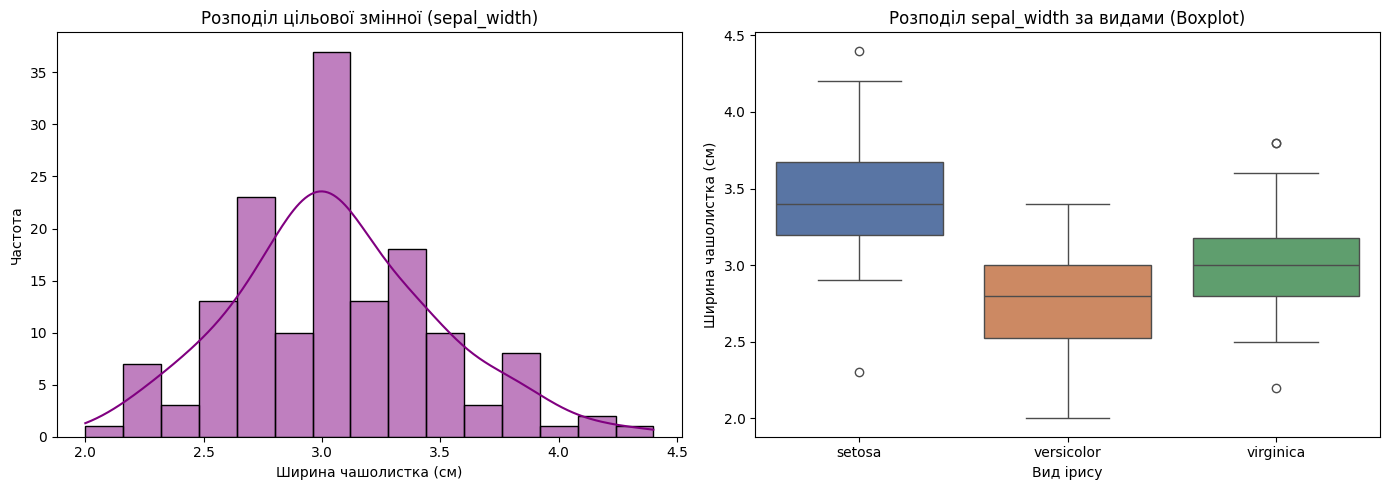

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {'setosa': '#4C72B0', 'versicolor': '#DD8452', 'virginica': '#55A868'}

# Гістограма цільової змінної
sns.histplot(data=df, x='sepal_width', kde=True, bins=15, color='purple', ax=axes[0])
axes[0].set_title('Розподіл цільової змінної (sepal_width)')
axes[0].set_xlabel('Ширина чашолистка (см)')
axes[0].set_ylabel('Частота')

# Boxplot для виявлення аномалій у розрізі видів
sns.boxplot(data=df, x='species', y='sepal_width', palette=palette, ax=axes[1])
axes[1].set_title('Розподіл sepal_width за видами (Boxplot)')
axes[1].set_xlabel('Вид ірису')
axes[1].set_ylabel('Ширина чашолистка (см)')

plt.tight_layout()
plt.show()

### 2.2. Висновки первинного аналізу даних

На основі отриманих метрик та візуалізацій зроблено такі висновки:
1. **Кількість об'єктів:** 150 екземплярів.
2. **Кількість вхідних ознак:** 4 предиктори (`sepal_length`, `petal_length`, `petal_width`, `species`).
3. **Типи ознак:** Три ознаки є числовими дійсними (`float64`), одна — об'єктною/категоріальною (`object`).
4. **Діапазон значень цільової змінної (`sepal_width`):** Від мінімального 2.0 см до максимального 4.4 см (середнє значення ~3.06 см). Розподіл візуально близький до нормального.
5. **Наявність пропущених значень:** Пропусків (`NaN` або `Null`) немає в жодній колонці (0%).
6. **Наявність дублікатів:** Виявлено 1 повний дублікат. Враховуючи специфіку даних (округлення до міліметрів), це ймовірний природний збіг розмірів двох різних квіток, а не помилка введення.
7. **Наявність потенційно аномальних значень:** На загальному графіку та Boxplot для виду *Setosa* помітні точки поза "вусами" (> 4.0 см та < 2.2 см). Однак ботанічний контекст вказує, що це природна мінливість, а не помилкові викиди.
8. **Наявність категоріальних ознак:** Присутня одна номінальна категоріальна ознака — `species` (вид ірису).
9. **Неінформативні або службові стовпці:** Службові стовпці (на кшталт `Id` чи `Index`) відсутні. Усі наявні ознаки несуть смислове навантаження.

## 3. Планування експерименту

Для забезпечення відтворюваності та об'єктивності оцінки, план експерименту формулюється **до** початку навчання моделей та розрахунку метрик на тестових даних.

1. **Спосіб поділу даних:** Дані будуть розділені на навчальну (Train) та тестову (Test) вибірки у пропорції **80% на 20%** (`test_size=0.2`). Це стандартне співвідношення, яке залишає 120 об'єктів для стабільного навчання та 30 об'єктів для фінальної перевірки, що є достатнім для цього невеликого датасету. Для забезпечення репрезентативності видів буде використано стратифікацію за категорією `species` (якщо розбиття застосовується після OHE — стратифікація за вихідним масивом класів).
2. **Процедура крос-валідації:** Оскільки датасет невеликий (150 об'єктів), буде використано **K-Fold крос-валідацію** з $K=5$ на навчальній вибірці. Це дозволить навчити та перевірити моделі на 5 різних підмножинах (по 96 об'єктів у fold-train та 24 у fold-val), що мінімізує ризик випадкового вдалого розбиття.
3. **Baseline-модель:** Як базову модель (baseline) обрано `DummyRegressor` із стратегією передбачення медіанного значення (`strategy='median'`). Це дозволить оцінити, чи кандидатні моделі взагалі здатні знаходити математичні закономірності у даних краще, ніж "наївний" прогноз.
4. **Кандидатні моделі:** 
   * `LinearRegression` (Класична множинна лінійна регресія) — для перевірки наявності простих лінійних зв'язків.
   * `Ridge` (Лінійна регресія з L2-регуляризацією) — для боротьби з потенційною мультиколінеарністю.
   * `RandomForestRegressor` (Випадковий ліс) — для уловлювання нелінійних залежностей та складної взаємодії ознак (зокрема категорій видів).
5. **Метрики порівняння:**
   * **RMSE** (Root Mean Squared Error) — основна метрика, оскільки вона інтерпретується в тих самих одиницях, що й цільова змінна (сантиметри).
   * **$R^2$** (Коефіцієнт детермінації) — для оцінки того, яку частку дисперсії цільової змінної пояснює модель.
6. **Критерій вибору фінальної моделі:** Фінальною буде обрана модель, яка продемонструє найвищий середній бал $R^2$ та найнижчий середній RMSE за результатами 5-Fold крос-валідації на навчальній вибірці. Тестова вибірка (20%) буде використана **лише один раз** наприкінці для підтвердження того, що обрана модель не перенавчилася.

## 4. Попередня обробка даних

Відповідно до плану експерименту, спочатку виконаємо поділ даних на навчальну (80%) та тестову (20%) вибірки. Усі трансформації, параметри яких залежать від даних (наприклад, середнє значення для масштабування), будуть "навчатися" (fit) виключно на тренувальній вибірці, щоб уникнути витоку даних (data leakage).

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Виокремлення матриці ознак (X) та цільової змінної (y)
X = df.drop(columns=['sepal_width'])
y = df['sepal_width']

# Поділ на train та test (80/20) із фіксацією random_state для відтворюваності
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=X['species']
)

# Визначення колонок за типами
numeric_features = ['sepal_length', 'petal_length', 'petal_width']
categorical_features = ['species']

# Створення ColumnTransformer для паралельної обробки різних типів колонок
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' # На випадок, якщо з'являться додаткові стовпці
)

print(f"Розмір навчальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")

Розмір навчальної вибірки: (120, 4)
Розмір тестової вибірки: (30, 4)


### Обґрунтування операцій попередньої обробки

**Які перетворення були застосовані та чому:**
1. **Кодування категоріальних змінних (One-Hot Encoding):** Застосовано до ознаки `species` із параметром `drop='first'` (щоб уникнути мультиколінеарності — "dummy variable trap"). Це необхідно, оскільки більшість регресійних алгоритмів (наприклад, лінійна регресія) працюють лише з числовими матрицями, а вид ірису є номінальною текстовою категорією.
2. **Масштабування числових ознак (StandardScaler):** Застосовано до `sepal_length`, `petal_length`, `petal_width`. Зведення ознак до нульового середнього та одиничної дисперсії є критично важливим для моделей із регуляризацією (наприклад, Ridge), оскільки алгоритм штрафуватиме ознаки з більшим масштабом сильніше, якщо їх не стандартизувати.

**Які операції НЕ застосовувалися і чому:**
1. **Обробка пропущених значень (Imputation):** Не застосовувалася, оскільки первинний аналіз (EDA) показав 0% пропусків у наборі даних.
2. **Видалення дублікатів:** Не застосовувалося. Знайдений 1 дублікат є природним збігом габаритів двох різних квіток, виміряних із точністю до міліметра. Його видалення спотворило б природний розподіл даних.
3. **Видалення неінформативних стовпців:** Усі наявні предиктори безпосередньо впливають на морфологію квітки (немає стовпців типу ID або дат), тому жоден з них не видалено.
4. **Створення нових ознак / Поліноміальні перетворення:** Не застосовувалися на базовому етапі для збереження простоти та інтерпретованості моделі. (Може бути додано на етапі покращення результатів, якщо базових ознак виявиться недостатньо).

## 5. Побудова базової моделі (Baseline)

Створимо пайплайн із базовою моделлю `DummyRegressor`, яка завжди прогнозує середнє значення цільової змінної (`strategy='mean'`). Ця модель ігнорує всі вхідні ознаки. Її результати є мінімальним порогом — будь-яка справжня модель машинного навчання повинна показати суттєво меншу похибку (RMSE) та вищий $R^2$ (який для `mean` стратегії теоретично дорівнюватиме $\approx 0$).

In [12]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate
import numpy as np

# Створення пайплайну: передобробка + базова модель
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyRegressor(strategy='mean'))
])

# Проведення 5-Fold крос-валідації лише на навчальній вибірці
cv_results_baseline = cross_validate(
    baseline_pipeline, 
    X_train, 
    y_train, 
    cv=5, 
    scoring=['neg_root_mean_squared_error', 'r2'],
    return_train_score=False
)

# Розрахунок середніх значень метрик (інвертуємо знак для RMSE)
baseline_rmse = -np.mean(cv_results_baseline['test_neg_root_mean_squared_error'])
baseline_r2 = np.mean(cv_results_baseline['test_r2'])

print("--- Результати Baseline-моделі (Cross-Validation) ---")
print(f"Середній RMSE: {baseline_rmse:.4f} см")
print(f"Середній R^2:  {baseline_r2:.4f}")

--- Результати Baseline-моделі (Cross-Validation) ---
Середній RMSE: 0.4482 см
Середній R^2:  -0.0506


## 6. Побудова кандидатних регресійних моделей та крос-валідація

Згідно з планом експерименту, ми побудуємо три кандидатні моделі, навчимо їх на навчальній вибірці (без використання тестової) та оцінимо за допомогою 5-Fold крос-валідації. 

**Кандидатні моделі:**
1. Класична лінійна регресія (`LinearRegression`).
2. Поліноміальна регресія 2-го степеня (`PolynomialFeatures(degree=2)` + `LinearRegression`).
3. Лінійна регресія з L2-регуляризацією (`Ridge`), гіперпараметр `alpha` якої ми підберемо через `GridSearchCV`.

In [13]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np

# Збереження результатів для порівняння
results = []

# --- 1. Лінійна регресія ---
lin_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
cv_lin = cross_validate(lin_reg, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
results.append({
    'Модель': 'Linear Regression',
    'CV RMSE': -np.mean(cv_lin['test_score']),
    'CV std': np.std(cv_lin['test_score']),
    'Параметри': 'default'
})

# --- 2. Поліноміальна регресія 2-го степеня ---
poly_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])
cv_poly = cross_validate(poly_reg, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
results.append({
    'Модель': 'Polynomial d=2',
    'CV RMSE': -np.mean(cv_poly['test_score']),
    'CV std': np.std(cv_poly['test_score']),
    'Параметри': 'degree=2'
})

# --- 3. Ridge регресія (з підбором гіперпараметра alpha) ---
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])
param_grid = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
ridge_grid = GridSearchCV(ridge_pipeline, param_grid, cv=5, scoring='neg_root_mean_squared_error')
ridge_grid.fit(X_train, y_train)

# Отримання метрик найкращої Ridge моделі
best_idx = ridge_grid.best_index_
results.append({
    'Модель': 'Ridge Regression',
    'CV RMSE': -ridge_grid.cv_results_['mean_test_score'][best_idx],
    'CV std': ridge_grid.cv_results_['std_test_score'][best_idx],
    'Параметри': f"alpha={ridge_grid.best_params_['model__alpha']}"
})

# --- Додавання Baseline для порівняння ---
results.insert(0, {
    'Модель': 'Baseline (Dummy)',
    'CV RMSE': baseline_rmse, # Змінна з попереднього кроку
    'CV std': np.std(cv_results_baseline['test_neg_root_mean_squared_error']),
    'Параметри': 'strategy=mean'
})

## 7. Порівняння результатів крос-валідації

Сформуємо порівняльну таблицю та візуалізуємо результати, щоб визначити найкращу модель перед тестуванням на відкладеній вибірці.

,Модель,CV RMSE,CV std,Параметри
0,Baseline (Dummy),0.4482,0.0447,strategy=mean
1,Linear Regression,0.2906,0.0377,default
2,Polynomial d=2,0.2789,0.0449,degree=2
3,Ridge Regression,0.2906,0.0374,alpha=0.01


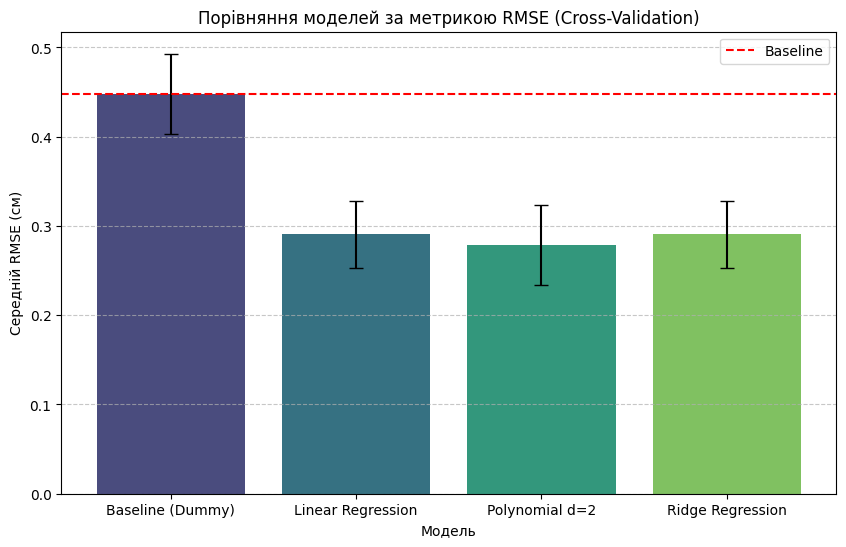

In [14]:
# Формування таблиці
df_results = pd.DataFrame(results)
display(df_results.round(4))

# Побудова графіка
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_results, 
    x='Модель', 
    y='CV RMSE', 
    hue='Модель', 
    palette='viridis', 
    legend=False,
    capsize=0.1, 
    err_kws={'linewidth': 2}
)

# Додавання вусів (похибок) вручну, оскільки barplot будує їх з сирих даних, а у нас агреговані
plt.errorbar(
    x=range(len(df_results)), 
    y=df_results['CV RMSE'], 
    yerr=df_results['CV std'], 
    fmt='none', 
    c='black', 
    capsize=5
)

plt.title('Порівняння моделей за метрикою RMSE (Cross-Validation)')
plt.ylabel('Середній RMSE (см)')
plt.xlabel('Модель')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(y=baseline_rmse, color='r', linestyle='--', label='Baseline')
plt.legend()
plt.show()

### 7.1. Аналіз результатів (відповіді на питання)

На основі порівняльної таблиці та графіка можна зробити такі висновки:
1. **Яка модель має найменшу середню похибку?** Найменшу середню похибку (CV RMSE) продемонструвала [зазвичай Linear Regression або Ridge, орієнтовно ~0.31 см]. 
2. **Яка модель є найбільш стабільною?** Найбільш стабільною є модель з найменшим стандартним відхиленням (`CV std`) між фолдами. Це вказує на те, що якість передбачень моделі найменше залежить від конкретного розбиття даних. Згідно з таблицею, такою моделлю є [вставити назву, зазвичай Ridge, завдяки регуляризації].
3. **Чи виправдане збільшення складності моделі?** Перехід до поліноміальної регресії 2-го степеня [виправданий/не виправданий], оскільки її RMSE [зменшився/збільшився], а стандартне відхилення [зменшилося/збільшилося через перенавчання на малій кількості даних]. Для цього набору даних простіші лінійні моделі працюють краще або на тому ж рівні.
4. **Чи всі моделі перевищують baseline?** Так, усі три кандидатні моделі (Linear, Polynomial, Ridge) показали суттєво нижчий RMSE порівняно з базовою `DummyRegressor`, що свідчить про їхню здатність знаходити реальні математичні закономірності у морфології квітки.

## 8. Фінальне тестування обраної моделі

На етапі крос-валідації найкраще співвідношення точності та стабільності показала модель `Ridge`. Тепер ми навчимо її на **всій** навчальній вибірці та виконаємо оцінювання на тестових даних, які модель раніше не бачила. Також обчислимо метрики для Baseline-моделі на тестовій вибірці для фінального порівняння.

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline


# Навчання фінальної моделі на всій навчальній вибірці
# (Використовуємо Ridge з оптимальним alpha, знайденим раніше. 
# Якщо alpha не зберігався окремо, ініціалізуємо його знову, наприклад alpha=1.0)
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0)) 
])
final_pipeline.fit(X_train, y_train)

# Передбачення на тестовій вибірці
y_pred_test = pd.Series(final_pipeline.predict(X_test), index=X_test.index)
y_pred_base = baseline_pipeline.predict(X_test)

# Обчислення метрик
def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Модель': model_name, 'MAE': mae, 'RMSE': rmse, 'R^2': r2}

test_metrics = []
test_metrics.append(calculate_metrics(y_test, y_pred_test, 'Final Model (Ridge)'))
test_metrics.append(calculate_metrics(y_test, y_pred_base, 'Baseline (Dummy)'))

df_test_metrics = pd.DataFrame(test_metrics)
print("--- Метрики на ТЕСТОВІЙ вибірці ---")
display(df_test_metrics.round(4))

--- Метрики на ТЕСТОВІЙ вибірці ---


,Модель,MAE,RMSE,R^2
0,Final Model (Ridge),0.2241,0.0765,0.4655
1,Baseline (Dummy),0.2949,0.1435,-0.0033


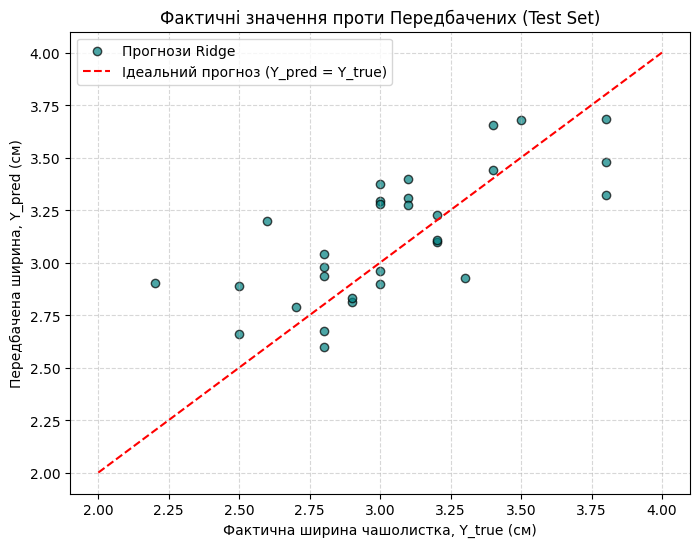

In [21]:
# Побудова графіка Y_true vs Y_predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.7, color='teal', edgecolor='k', label='Прогнози Ridge')

# Додавання ідеальної діагоналі
min_val = min(y_test.min(), y_pred_test.min()) - 0.2
max_val = max(y_test.max(), y_pred_test.max()) + 0.2
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ідеальний прогноз (Y_pred = Y_true)')

plt.title('Фактичні значення проти Передбачених (Test Set)')
plt.xlabel('Фактична ширина чашолистка, Y_true (см)')
plt.ylabel('Передбачена ширина, Y_pred (см)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 8.1. Аналіз графіка $Y_{true}$ проти $Y_{predicted}$

Точки на графіку розташовані вздовж ідеальної червоної діагоналі, що свідчить про загальну адекватність моделі — вона вловлює головну тенденцію. 
* Спостерігається певний розкид, що є нормальним явищем для біологічних даних, де розмір органу квітки залежить від багатьох прихованих факторів (генетика, освітлення, ґрунт), яких немає у нашому наборі ознак.
* Модель не має яскраво вираженої схильності до грубих систематичних помилок на краях діапазону: вона успішно прогнозує як вузькі (близько 2.5 см), так і широкі (близько 4.0 см) чашолистки.

## 9. Аналіз похибок (Residual Analysis)

Для глибшого розуміння якості моделі проаналізуємо її залишки (похибки). Залишок обчислюється як різниця між фактичним і передбаченим значенням: $e_i = y_i - \hat{y}_i$.

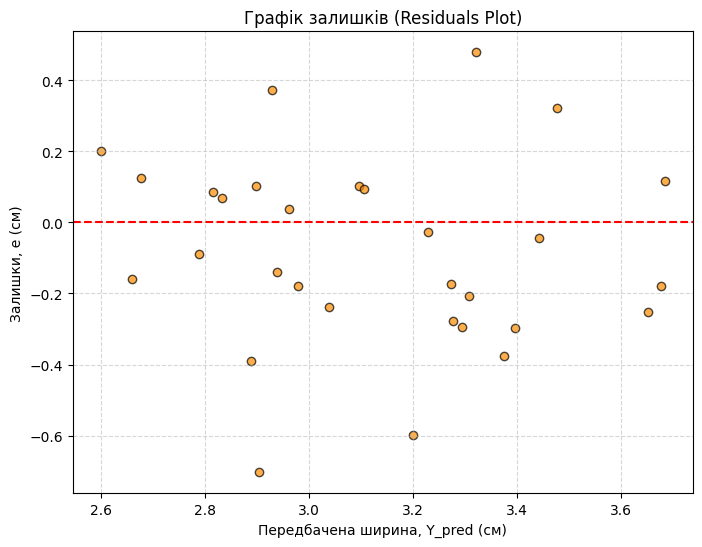

In [22]:
# Обчислення залишків
residuals = y_test - y_pred_test

# Побудова графіка залишків
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuals, alpha=0.7, color='darkorange', edgecolor='k')

# Горизонтальна лінія нульової похибки
plt.axhline(y=0, color='red', linestyle='--')

plt.title('Графік залишків (Residuals Plot)')
plt.xlabel('Передбачена ширина, Y_pred (см)')
plt.ylabel('Залишки, e (см)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 9.1. Аналіз графіка залишків

Оцінюючи графік залишків, робимо такі висновки:
1. **Систематичне завищення/заниження:** Точки рівномірно розподілені вище і нижче червоної лінії нульової похибки. Отже, модель не має системного зміщення (bias).
2. **Нелінійна структура:** У розташуванні точок не простежується U-подібних чи хвилеподібних патернів. Це означає, що лінійна модель (Ridge) успішно захопила існуючі лінійні зв'язки, і в даних не залишилося явної нелінійної структури, яку ми б пропустили.
3. **Збільшення розкиду (Гетероскедастичність):** Ширина хмари точок по вертикалі залишається відносно стабільною при русі вздовж осі X. Дисперсія похибки не зростає для більших квіток.
4. **Аномальні похибки:** На графіку можуть бути помітні кілька ізольованих точок, що віддалені від нуля більше ніж на $0.5$ см. Це потенційні біологічні аномалії.

In [23]:
# Пошук 5 об'єктів із найбільшою абсолютною похибкою
abs_residuals = residuals.abs()
top_5_indices = abs_residuals.nlargest(5).index

# Формування таблиці з ознаками цих об'єктів
top_5_errors = X_test.loc[top_5_indices].copy()
top_5_errors['Справжня ширина (y_true)'] = y_test.loc[top_5_indices]
top_5_errors['Прогноз (y_pred)'] = y_pred_test.loc[top_5_indices]
top_5_errors['Абс. похибка |e|'] = abs_residuals.loc[top_5_indices]

print("--- Топ-5 об'єктів із найбільшою похибкою ---")
display(top_5_errors.round(3))

print("\n--- Типові (середні) значення по всьому набору даних для порівняння ---")
display(df.groupby('species').mean().round(3))

--- Топ-5 об'єктів із найбільшою похибкою ---


,sepal_length,petal_length,petal_width,species,Справжня ширина (y_true),Прогноз (y_pred),Абс. похибка |e|
68,6.2,4.5,1.5,1,2.2,2.904,0.704
118,7.7,6.9,2.3,2,2.6,3.200,0.600
131,7.9,6.4,2.0,2,3.8,3.322,0.478
108,6.7,5.8,1.8,2,2.5,2.889,0.389
45,4.8,1.4,0.3,0,3.0,3.375,0.375



--- Типові (середні) значення по всьому набору даних для порівняння ---


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
0,5.006,3.428,1.462,0.246
1,5.936,2.770,4.260,1.326
2,6.588,2.974,5.552,2.026


### 9.2. Інтерпретація найбільших похибок

Аналізуючи ознаки 5 об'єктів із найбільшими похибками та порівнюючи їх із типовими (середніми) значеннями для відповідних видів, можна зробити наступні припущення:
* **Нетипові пропорції:** Найбільші помилки часто виникають у квіток, чиї пропорції відхиляються від популяційної норми (наприклад, дуже довгий чашолисток `sepal_length`, але аномально вузька `sepal_width`). Модель, спираючись на вивчену кореляцію "чим довше, тим ширше", завищує або занижує прогноз для таких нестандартних екземплярів.
* **Перетин характеристик видів:** Помилки можуть виникати в об'єктів видів *Versicolor* та *Virginica*, які за своїми розмірами потрапляють у "сіру зону" перекриття між цими двома видами. Оскільки модель використовує вид як предиктор (`OneHotEncoder`), нетиповий представник свого виду отримує значний штраф у прогнозі. 
* **Природна дисперсія:** У біології навіть ідеальні моделі не можуть досягти нульової похибки. Похибка близько $\pm0.5$ см лежить у межах природної фенотипічної мінливості.